# telecom_churn_sample dataset
- telecom_churn_sample dataset is the integration of both the opencellid dataset  (~2700 rows) and expresso_sample dataset (100,000 rows)


# OpenCellID and  Expresso integration
- OpenCellID  and  Expresso datasets do not share a direct key.
- Workflow for the integration:

 Geospatial aggregation of network quality dataset (OpenCellID)→ Region-level features → Join to customer dataset (Expresso)

 - OpenCellID = tower-level
- Expresso = customer-level (with REGION)
1. Convert tower lat/lon → Senegal administrative region
2. Aggregate network KPIs per region
3. Join to customer REGION


# Phase 1 Aggregate Network to Region Level


# Step 1 Mount Google Drive

**Authorize access when prompted.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

# Step 2  Install and import libraries
- Core
  - json: parsing, encoding, and manipulating data in JavaScript Object Notation (JSON) format.
  - requests: interacting with web APIs.
  - numpy: computing multi-dimensional array operations.
  - pandas: manipulating structured data

- Geospatial
  - geopandas: allow spatial operations on geometric types for geographic data
  - shapely: planar geometric objects like points, lines, and polygons.
  - pyproj: performing cartographic transformations and geodetic computations to convert coordinates between different reference systems.
  - folium: interactive high-quality web maps.


- Spatial Join Optimization
  - rtree: indexing library to speeds up spatial queries and joins by organizing geometries into a hierarchical tree structure.

- Formatting
  - rich: renders rich text, including colors, tables, and syntax-highlighted JSON

In [ ]:
# !pip install requests numpy pandas geopandas shapely pyproj rtree folium rich

In [ ]:
import requests
from rich import print as rprint
import json

import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point
import folium


# view all columns in a pandas DataFrame
pd.set_option("display.max_columns", None)

# Step 3 Define File Paths




In [ ]:
# opencellid_file = "/path/to/opencellid_senegal_2026_02.csv"
# expresso_sample_file = "/path/to/expresso_sample_100k.csv"
# geojson_file = "/path/to/senegal_regions.geojson"
# geojson_regions_file = "/path/to/senegal_regions.geojson"
# geojson_departments_file= "/path/to/senegal_departments.geojson"
# geojson_arrondissements_file= "/path/to/senegal_arrondissements.geojson"
# telecom_churn_sample_file = "/path/to/telecom_churn_sample.csv"

# Step 4 Load OpenCellID


In [ ]:
opencellid_cols = ['radio', 'mcc', 'net', 'area', 'cell', 'unit', 'lon', 'lat', 'range_val', 'samples', 'changeable', 'created', 'updated', 'averageSignal']
opencellid = pd.read_csv(opencellid_file, header=None)

In [1]:
opencellid.columns = opencellid_cols

NameError: name 'opencellid_cols' is not defined

In [ ]:
opencellid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2709 entries, 0 to 2708
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   radio          2709 non-null   object 
 1   mcc            2709 non-null   int64  
 2   net            2709 non-null   int64  
 3   area           2709 non-null   int64  
 4   cell           2709 non-null   int64  
 5   unit           2709 non-null   int64  
 6   lon            2709 non-null   float64
 7   lat            2709 non-null   float64
 8   range_val      2709 non-null   int64  
 9   samples        2709 non-null   int64  
 10  changeable     2709 non-null   int64  
 11  created        2709 non-null   int64  
 12  updated        2709 non-null   int64  
 13  averageSignal  2709 non-null   int64  
dtypes: float64(2), int64(11), object(1)
memory usage: 296.4+ KB


In [ ]:
# Check missing data
opencellid.isnull().sum()

,0
radio,0
mcc,0
net,0
area,0
cell,0
unit,0
lon,0
lat,0
range_val,0
samples,0


In [ ]:
opencellid.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0


# Step 5 Convert OpenCellID to GeoDataFrame
- **Convert OpenCellID cell tower lon/lat columns into region polygons to match Expresso REGION column**
- Use Senegal region boundaries (GeoJSON shapefile) file: senegal_regions.geojson
1. Download the GeoJSON shapefile for Senegal Admin Level 1.
> Use geoBoundaries:
An open database of political administrative boundaries https://www.geoboundaries.org/

>Runfola, D. et al. (2020) geoBoundaries: A global database of political administrative boundaries. PLoS ONE 15(4): e0231866. https://doi.org/10.1371/journal.pone.0231866





2. Load Senegal Regions into GeoPandas
3. Perform a spatial join (point-in-polygon) between OpenCellID cell tower lon/lat and region polygons.


### Senegal Admistrative Levels

| Country | Region | Department |Arrondissement |
| :--- | :--- | :--- |:--- |
| Senegal | 14 regions | 45 department |121 arrondissement |
| ![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e1/Senegal%2C_administrative_divisions_in_colour_2.svg/500px-Senegal%2C_administrative_divisions_in_colour_2.svg.png) | ![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Senegal%2C_administrative_divisions_-_en_-_monochrome.svg/500px-Senegal%2C_administrative_divisions_-_en_-_monochrome.svg.png) |![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e1/Senegal%2C_administrative_divisions_in_colour_2.svg/960px-Senegal%2C_administrative_divisions_in_colour_2.svg.png) |![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Senegal_arrondissements.png/500px-Senegal_arrondissements.png) |

| Country | Region | Department |Arrondissement |
| :--- | :--- | :--- |:--- |
| ADM0 | ADM1 | ADM2 |ADM3 |
| ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM0/geoBoundaries-SEN-ADM0-PREVIEW.png) | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM1/geoBoundaries-SEN-ADM1-PREVIEW.png) |![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM2/geoBoundaries-SEN-ADM2-PREVIEW.png) |![](https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/SEN/ADM3/geoBoundaries-SEN-ADM3-PREVIEW.png) |

| Admin | Localname | Preview |
| :--- | :--- | :--- |
| ADM0 | Country | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM0/geoBoundaries-SEN-ADM0-PREVIEW.png)|

| Admin | Localname | Preview |
| :--- | :--- | :--- |
| ADM1 | Region | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM1/geoBoundaries-SEN-ADM1-PREVIEW.png)|

| Admin | Localname | Preview |
| :--- | :--- | :--- |
| ADM2 | Department | ![](https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/9469f09592ced973a3448cf66b6100b741b64c0d/releaseData/gbOpen/SEN/ADM2/geoBoundaries-SEN-ADM2-PREVIEW.png)|

| Level | Localname | Preview |
| :--- | :--- | :--- |
| ADM3 | Arrondissement | ![](https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/SEN/ADM3/geoBoundaries-SEN-ADM3-PREVIEW.png)|



### geoBoundaries-SEN-ADM1.geojson
>GeoJSON file, specialized JSON format, for geographic data of Senegal regions

In [ ]:
# Download the GeoJSON shapefile for Senegal Admin Level 1 (to match REGION in expresso)
# Use geoBoundaries public API

geojson_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/SEN/ADM1/geoBoundaries-SEN-ADM1.geojson"

response = requests.get(geojson_url)

# Check if request worked
if response.status_code == 200:
    with open(geojson_regions_file, "wb") as f:
        f.write(response.content)
    print("Regions Download completed")
else:
    print("Regions Download failed. Status code:", response.status_code)

Regions Download completed


In [ ]:
# Load Senegal Regions into GeoPandas
gdf_regions = gpd.read_file(geojson_regions_file)

print(gdf_regions)

      shapeName shapeISO                  shapeID shapeGroup shapeType  \
0         Dakar    SN-DK  71046170B16569890219484        SEN      ADM1   
1      Diourbel    SN-DB  71046170B89912390768536        SEN      ADM1   
2        Fatick    SN-FK  71046170B84527172065489        SEN      ADM1   
3      Kaffrine    SN-KA   71046170B9856693808493        SEN      ADM1   
4       Kaolack    SN-KL  71046170B19471834738959        SEN      ADM1   
5         Kolda    SN-KD  71046170B66864032803639        SEN      ADM1   
6         Louga    SN-LG  71046170B63374102885919        SEN      ADM1   
7         Matam    SN-MT  71046170B85295751834134        SEN      ADM1   
8   Saint Louis    SN-SL  71046170B37999982332216        SEN      ADM1   
9       Sedhiou    SN-SE  71046170B19178449543377        SEN      ADM1   
10  Tambacounda    SN-TC  71046170B85662395344337        SEN      ADM1   
11        Thies    SN-TH  71046170B89315153043645        SEN      ADM1   
12   Ziguinchor    SN-ZG  71046170B262

In [ ]:
# Create pretty interactive map for Senegal regions
m = gdf_regions.explore(
    column="shapeName",  # Color polygons by region name
    cmap="Set2",         # color palette
    tooltip="shapeName", # Show name when hovering
    popup=True           # Show all properties when clicking
)
m

<Axes: >

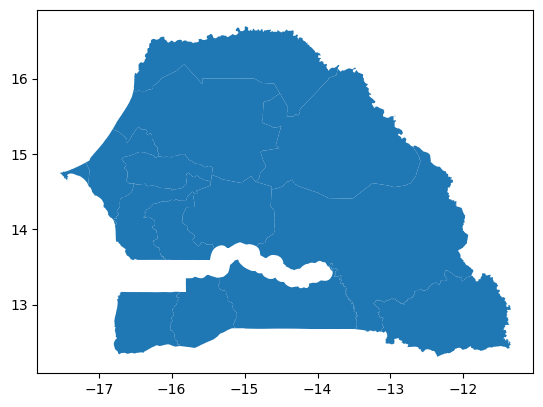

In [ ]:
# View the actual map shapes
gdf_regions.plot()

In [ ]:
# RUNNING THIS WILL LOAD A LOT OF NUMBERS OF LOGITUDE AND LATITUIDE

# # View the attribute table of senegal_regions.geojson
# # ! head /path/to/senegal_regions.geojson

# {
# "type": "FeatureCollection",
# "crs": { "type": "name", "properties": { "name": "urn:ogc:def:crs:OGC:1.3:CRS84" } },
# "features": [
# { "type": "Feature", "properties": { "shapeName": "Dakar", "shapeISO": "SN-DK", "shapeID": "71046170B16569890219484", "shapeGroup": "SEN", "shapeType": "ADM1" }, "geometry": { "type": "MultiPolygon", "coordinates": [ [ [ [ -17.39917595299994, 14.671295529000076 ], [ -17.399261806999959, 14.671297855000034 ], [ -17.399320974999966, 14.671274749000077 ], [ -17.
...
# 14.592126266000037 ], [ -17.147795048999967, 14.590697431000024 ], [ -17.146688716999961, 14.589514859000076 ], [ -17.145534257999941, 14.588152003000062 ], [ -17.144621292999943, 14.586814029000038 ] ] ] ] } },
# {
#     ...


In [ ]:
# RUNNING THIS WILL LOAD A LOT OF NUMBERS OF LOGITUDE AND LATITUIDE

# with open(geojson_regions_file) as f:
#     regions = json.load(f)

# # print the geojson_regions_file JSON with indentation
# rprint(regions)

# {
#     'type': 'FeatureCollection',
#     'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}},
#     'features': [
#         {
#             'type': 'Feature',
#             'properties': {
#                 'shapeName': 'Dakar',
#                 'shapeISO': 'SN-DK',
#                 'shapeID': '71046170B16569890219484',
#                 'shapeGroup': 'SEN',
#                 'shapeType': 'ADM1'
#             },
#             'geometry': {
#                 'type': 'MultiPolygon',
#                 'coordinates': [
#                     [
#                         [
#                             [-17.39917595299994, 14.671295529000076],
#                             [-17.39926180699996, 14.671297855000034],
#                             [-17.399320974999966, 14.671274749000077],


# ....

#                         [-13.122416880999936, 12.641730004000067],
#                         [-13.12313878599997, 12.641183738000052],
#                         [-13.12325895999993, 12.641112276000058]
#                     ]
#                 ]
#             }
#         }
#     ]
# }

In [ ]:
print(gdf_regions.head())

  shapeName shapeISO                  shapeID shapeGroup shapeType  \
0     Dakar    SN-DK  71046170B16569890219484        SEN      ADM1   
1  Diourbel    SN-DB  71046170B89912390768536        SEN      ADM1   
2    Fatick    SN-FK  71046170B84527172065489        SEN      ADM1   
3  Kaffrine    SN-KA   71046170B9856693808493        SEN      ADM1   
4   Kaolack    SN-KL  71046170B19471834738959        SEN      ADM1   

                                            geometry  
0  MULTIPOLYGON (((-17.39918 14.6713, -17.39926 1...  
1  POLYGON ((-16.17706 14.96405, -16.17836 14.963...  
2  POLYGON ((-16.52543 14.60762, -16.5241 14.6044...  
3  POLYGON ((-15.46222 14.62909, -15.46515 14.607...  
4  POLYGON ((-16.08997 13.59347, -16.08534 13.593...  


In [ ]:
# RUNNING THIS WILL LOAD A LOT OF NUMBERS OF LOGITUDE AND LATITUIDE

# # Display of gdf_regions
# gdf_regions.head().style.set_properties(**{
#     'background-color': '#f9f9f9',
#     'color': 'black',
#     'border-color': 'white'
# }).set_caption("Senegal Administrative Regions")


# Senegal Administrative Regions
#  	shapeName	shapeISO	shapeID	shapeGroup	shapeType	geometry
#     MULTIPOLYGON (((-17.39917595299994 14.671295529000076,
#                     -17.39926180699996 14.671297855000034,
#                     -17.399320974999966 14.671274749000077,
#                     ....

#                     -17.14553425799994 14.588152003000062,
#                     -17.144621292999943 14.586814029000038)))




In [ ]:
# Display only the first few rows of gdf_regions without geometry
gdf_regions.drop(columns='geometry').head().style.set_properties(**{
    'background-color': '#f9f9f9',
    'color': 'black',
    'border-color': 'white'
}).set_caption("Senegal Administrative Regions")

,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,Dakar,SN-DK,71046170B16569890219484,SEN,ADM1
1,Diourbel,SN-DB,71046170B89912390768536,SEN,ADM1
2,Fatick,SN-FK,71046170B84527172065489,SEN,ADM1
3,Kaffrine,SN-KA,71046170B9856693808493,SEN,ADM1
4,Kaolack,SN-KL,71046170B19471834738959,SEN,ADM1


### Coordinate Reference System (CRS)
> mathematical framework that defines how the three-dimensional, curved surface of the Earth is represented on a two-dimensional map using specific coordinates.

>EPSG:4326 is the most widely used Coordinate Reference System (CRS) in the world, serving as the default for GPS, web mapping (like Google Maps), and most raw spatial data formats (GeoJSON, CSV).

> to ensure the spatial data uses the global standard for latitude and longitude, we  need to convert the coordinates of the polygons into WGS84 and perform a Coordinate Reference System (CRS) transformation

> WGS84 is the standard system used by GPS and web maps (like Google Maps or Folium).

In [ ]:
# Check CRS
print("CRS:", gdf_regions.crs)

CRS: EPSG:4326


In [ ]:
# Eensure the spatial data uses the global standard for latitude and longitude.
gdf_regions = gdf_regions.to_crs("EPSG:4326")

In [ ]:
# Check region name column
gdf_regions.columns

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='object')

In [ ]:
# Set region name column
region_col = "shapeName"

### Create Point objects
>Create a sequence of Shapely Point objects by pairing longitude (lon) as ($x$) and latitude (lat) as ($y$) coordinates from the two separate columns opencellid['lon']and opencellid['lat'] to represent specific geographic locations.

In [ ]:
# Create a sequence of Shapely Point objects
geometry = [Point(xy) for xy in zip(opencellid['lon'], opencellid['lat'])]

In [ ]:
geometry[:5]

[<POINT (-17.471 14.709)>,
 <POINT (-17.465 14.714)>,
 <POINT (-17.467 14.718)>,
 <POINT (-17.439 14.719)>,
 <POINT (-17.486 14.756)>]

In [ ]:
# Convert opencellid pandas dataframe to gdf_cells GeoDataFrame
gdf_cells = gpd.GeoDataFrame(
    opencellid,
    geometry=geometry,
    crs="EPSG:4326"
)

In [ ]:
gdf_cells.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0,POINT (-17.4709 14.7086)
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0,POINT (-17.4654 14.7142)
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0,POINT (-17.4669 14.7178)
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0,POINT (-17.4391 14.7191)
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0,POINT (-17.4865 14.7555)


In [ ]:
# View points of cell towers on a pretty map
gdf_cells.explore(marker_type='circle_marker', color='red', radius=5)

In [ ]:
# Spatial Join (Point-in-Polygon)
# Assign each tower to a region.

# Perform a spatial join to link tower points with their containing region polygons
# based on geographic coordinates.
gdf_cells_with_region = gpd.sjoin(
    gdf_cells,
    gdf_regions[[region_col, "geometry"]],
    how="left",
    predicate="within"
)

In [ ]:
# Standardizes the resulting column name to "REGION"
gdf_cells_with_region = gdf_cells_with_region.rename(
    columns={region_col: "REGION"}
)

In [ ]:
# View points of cell towers within a region on a pretty map
gdf_cells_with_region.explore(marker_type='circle_marker', color='red', radius=5)

In [ ]:
# Generates a frequency distribution of towers per region to verify the join
print(gdf_cells_with_region["REGION"].value_counts(dropna=False))

REGION
Dakar          1156
Saint Louis     537
Thies           453
Fatick          220
Louga           149
Ziguinchor      110
NaN              84
Name: count, dtype: int64


In [ ]:
gdf_cells_with_region.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,index_right,REGION
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0,POINT (-17.4709 14.7086),0.0,Dakar
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0,POINT (-17.4654 14.7142),0.0,Dakar
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0,POINT (-17.4669 14.7178),0.0,Dakar
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0,POINT (-17.4391 14.7191),0.0,Dakar
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0,POINT (-17.4865 14.7555),0.0,Dakar


### **Now every cell tower has a REGION label.**

# Phase 2 Region-level features


# Step 6 Aggregate Network Features per Region



In [ ]:
# Create region-relevant features.
network_region_features = (
    gdf_cells_with_region
    .groupby("REGION")
    .agg(
        tower_count=("cell", "count"),
        avg_range=("range_val", "mean"),
        avg_samples=("samples", "mean"),
        avg_signal=("averageSignal", "mean")
    )
    .reset_index()
)

In [ ]:
network_region_features

,REGION,tower_count,avg_range,avg_samples,avg_signal
0,Dakar,1156,1125.068339,11.618512,0.0
1,Fatick,220,1477.218182,17.154545,0.0
2,Louga,149,1820.348993,21.463087,0.0
3,Saint Louis,537,2000.029795,15.186220,0.0
4,Thies,453,1420.562914,15.445916,0.0
5,Ziguinchor,110,1652.418182,18.590909,0.0


In [ ]:
# Add coverage_index = tower_count * avg_range
network_region_features["coverage_index"] = (
    network_region_features["tower_count"] *
    network_region_features["avg_range"]
)

# Add network_quality_score = avg_signal * avg_samples
network_region_features["network_quality_score"] = (
    network_region_features["avg_signal"] *
    network_region_features["avg_samples"]
)

In [ ]:
network_region_features

,REGION,tower_count,avg_range,avg_samples,avg_signal,coverage_index,network_quality_score
0,Dakar,1156,1125.068339,11.618512,0.0,1300579.0,0.0
1,Fatick,220,1477.218182,17.154545,0.0,324988.0,0.0
2,Louga,149,1820.348993,21.463087,0.0,271232.0,0.0
3,Saint Louis,537,2000.029795,15.186220,0.0,1074016.0,0.0
4,Thies,453,1420.562914,15.445916,0.0,643515.0,0.0
5,Ziguinchor,110,1652.418182,18.590909,0.0,181766.0,0.0


# Step 7 Load Expresso Dataset


In [ ]:
expresso_sample = pd.read_csv(expresso_sample_file)

In [ ]:
expresso_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         100000 non-null  object 
 1   REGION          60844 non-null   object 
 2   TENURE          100000 non-null  object 
 3   MONTANT         65059 non-null   float64
 4   FREQUENCE_RECH  65059 non-null   float64
 5   REVENUE         66484 non-null   float64
 6   ARPU_SEGMENT    66484 non-null   float64
 7   FREQUENCE       66484 non-null   float64
 8   DATA_VOLUME     50813 non-null   float64
 9   ON_NET          63663 non-null   float64
 10  ORANGE          58621 non-null   float64
 11  TIGO            40369 non-null   float64
 12  ZONE1           7909 non-null    float64
 13  ZONE2           6493 non-null    float64
 14  MRG             100000 non-null  object 
 15  REGULARITY      100000 non-null  int64  
 16  TOP_PACK        58264 non-null   object 
 17  FREQ_TOP_PA

In [ ]:
# Check missing data
expresso_sample.isnull().sum()

,0
user_id,0
REGION,39156
TENURE,0
MONTANT,34941
FREQUENCE_RECH,34941
REVENUE,33516
ARPU_SEGMENT,33516
FREQUENCE,33516
DATA_VOLUME,49187
ON_NET,36337


In [ ]:
expresso_sample.head()

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,K > 24 month,8650.0,37.0,8650.0,2883.0,38.0,2593.0,3.0,39.0,1.0,NaN,NaN,NO,59,"Data: 100 F=40MB,24H",20.0,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,K > 24 month,1000.0,2.0,980.0,327.0,2.0,1362.0,NaN,1.0,9.0,NaN,NaN,NO,8,"Data:490F=1GB,7d",2.0,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,1043.0,4.0,NaN,NaN,NaN,NaN,NO,8,NaN,NaN,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,K > 24 month,250.0,1.0,250.0,83.0,2.0,389.0,5.0,NaN,NaN,NaN,NaN,NO,58,"Data: 200 F=100MB,24H",1.0,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NO,15,NaN,NaN,1


In [ ]:
print(expresso_sample["REGION"].value_counts(dropna=False))

REGION
NaN            39156
DAKAR          23859
THIES           8376
SAINT-LOUIS     5619
KAOLACK         4612
LOUGA           4582
DIOURBEL        3158
TAMBACOUNDA     2557
KAFFRINE        2011
KOLDA           1762
FATICK          1747
MATAM           1385
ZIGUINCHOR       982
SEDHIOU          145
KEDOUGOU          49
Name: count, dtype: int64


In [ ]:
# Comvert network_region_features["REGION"] to upper case
# to match expresso REGION
network_region_features["REGION"] = network_region_features["REGION"].str.strip().str.upper()
network_region_features["REGION"]

,REGION
0,DAKAR
1,FATICK
2,LOUGA
3,SAINT LOUIS
4,THIES
5,ZIGUINCHOR


# Phase 3 Join Network dataset to Customer dataset

# Step 8 Join network_region_features to expresso_sample
**telecom_churn_sample dataset is the result of merging network_region_features extracted from OpencelliD to expresso_sample**


In [ ]:
telecom_churn_sample = expresso_sample.merge(
    network_region_features,
    on="REGION",
    how="left"
)

In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                100000 non-null  object 
 1   REGION                 60844 non-null   object 
 2   TENURE                 100000 non-null  object 
 3   MONTANT                65059 non-null   float64
 4   FREQUENCE_RECH         65059 non-null   float64
 5   REVENUE                66484 non-null   float64
 6   ARPU_SEGMENT           66484 non-null   float64
 7   FREQUENCE              66484 non-null   float64
 8   DATA_VOLUME            50813 non-null   float64
 9   ON_NET                 63663 non-null   float64
 10  ORANGE                 58621 non-null   float64
 11  TIGO                   40369 non-null   float64
 12  ZONE1                  7909 non-null    float64
 13  ZONE2                  6493 non-null    float64
 14  MRG                    100000 non-nul

In [ ]:
telecom_churn_sample.isnull().sum()

,0
user_id,0
REGION,39156
TENURE,0
MONTANT,34941
FREQUENCE_RECH,34941
REVENUE,33516
ARPU_SEGMENT,33516
FREQUENCE,33516
DATA_VOLUME,49187
ON_NET,36337


In [ ]:
telecom_churn_sample.head()

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN,tower_count,avg_range,avg_samples,avg_signal,coverage_index,network_quality_score
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,K > 24 month,8650.0,37.0,8650.0,2883.0,38.0,2593.0,3.0,39.0,1.0,NaN,NaN,NO,59,"Data: 100 F=40MB,24H",20.0,0,1156.0,1125.068339,11.618512,0.0,1300579.0,0.0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,K > 24 month,1000.0,2.0,980.0,327.0,2.0,1362.0,NaN,1.0,9.0,NaN,NaN,NO,8,"Data:490F=1GB,7d",2.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,1043.0,4.0,NaN,NaN,NaN,NaN,NO,8,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,K > 24 month,250.0,1.0,250.0,83.0,2.0,389.0,5.0,NaN,NaN,NaN,NaN,NO,58,"Data: 200 F=100MB,24H",1.0,0,149.0,1820.348993,21.463087,0.0,271232.0,0.0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NO,15,NaN,NaN,1,1156.0,1125.068339,11.618512,0.0,1300579.0,0.0


# Step 9 Add Departments-level features

In [ ]:
# Download the GeoJSON shapefile for Senegal Admin Level 2 (Depatments)
# Use geoBoundaries public API

geojson_departments_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/SEN/ADM2/geoBoundaries-SEN-ADM2.geojson"

response = requests.get(geojson_departments_url)

# Check if request worked
if response.status_code == 200:
    with open(geojson_departments_file, "wb") as f:
        f.write(response.content)
    print("Departments Download completed")
else:
    print("Departments Download failed. Status code:", response.status_code)

Departments Download completed


In [ ]:
# Load Senegal Depatments into GeoPandas
gdf_depatments = gpd.read_file(geojson_departments_file)

print(gdf_depatments.head())
print(gdf_depatments.tail())
print("CRS:", gdf_depatments.crs)

    shapeName shapeISO                  shapeID shapeGroup shapeType  \
0       Bakel           50182788B16013842146029        SEN      ADM2   
1      Bambey           50182788B75300917140294        SEN      ADM2   
2     Bignona           50182788B19391387689457        SEN      ADM2   
3   Birkelane           50182788B56779252201559        SEN      ADM2   
4  Bounkiling           50182788B68388966372963        SEN      ADM2   

                                            geometry  
0  POLYGON ((-11.88782 13.38481, -11.88863 13.386...  
1  POLYGON ((-16.38592 15.02258, -16.39115 15.023...  
2  POLYGON ((-15.9775 12.88596, -15.97445 12.8904...  
3  POLYGON ((-15.59024 13.8291, -15.5897 13.82993...  
4  POLYGON ((-15.9775 12.88596, -15.97388 12.8884...  
      shapeName shapeISO                  shapeID shapeGroup shapeType  \
40  Tambacounda           50182788B74600736318601        SEN      ADM2   
41        Thies           50182788B65872214095625        SEN      ADM2   
42     Tivaoune

In [ ]:
# Ensure CRS is WGS84
gdf_depatments = gdf_depatments.to_crs("EPSG:4326")

In [ ]:
# Check depatment name column
gdf_depatments.columns

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='object')

In [ ]:
# Set depatment name column
department_col = "shapeName"

In [ ]:
# Convert OpenCellID to GeoDataFrame

geometry = [Point(xy) for xy in zip(opencellid['lon'], opencellid['lat'])]

gdf_cells = gpd.GeoDataFrame(
    opencellid,
    geometry=geometry,
    crs="EPSG:4326"
)

In [ ]:
# Spatial Join (Point-in-Polygon)
# Assign each tower to a department.

gdf_cells_with_department = gpd.sjoin(
    gdf_cells,
    gdf_depatments[[department_col, "geometry"]],
    how="left",
    predicate="within"
)

gdf_cells_with_department = gdf_cells_with_department.rename(
    columns={department_col: "department"}
)

In [ ]:
gdf_cells_with_department.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,index_right,department
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0,POINT (-17.4709 14.7086),6.0,Dakar
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0,POINT (-17.4654 14.7142),6.0,Dakar
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0,POINT (-17.4669 14.7178),6.0,Dakar
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0,POINT (-17.4391 14.7191),6.0,Dakar
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0,POINT (-17.4865 14.7555),6.0,Dakar


In [ ]:
print(gdf_cells_with_department["department"].value_counts(dropna=False))

department
Dakar          745
Dagana         260
Rufisque       237
Mbour          221
Saint Louis    176
Tivaoune       173
Pikine         161
Foundiougne    143
Kebemer        112
Oussouye       110
Podor          101
NaN             84
Fatick          77
Thies           59
Louga           37
Guediawaye      13
Name: count, dtype: int64


In [ ]:
# 1. Drop the existing 'index_right' from the previous join
gdf_cells_with_department_no_index_right = gdf_cells_with_department.drop(columns=['index_right'], errors='ignore')

# 2. Perform the second join for Regions
gdf_cells_with_department_region = gpd.sjoin(
    gdf_cells_with_department_no_index_right,
    gdf_regions[[region_col, "geometry"]],
    how="left",
    predicate="within"
)

In [ ]:
gdf_cells_with_department_region = gdf_cells_with_department_region.rename(
    columns={"shapeName": "REGION"}
)

print(gdf_cells_with_department_region[["REGION", "department"]].value_counts(dropna=False))

REGION       department 
Dakar        Dakar          745
Saint Louis  Dagana         260
Dakar        Rufisque       237
Thies        Mbour          221
Saint Louis  Saint Louis    176
Thies        Tivaoune       173
Dakar        Pikine         161
Fatick       Foundiougne    143
Louga        Kebemer        112
Ziguinchor   Oussouye       110
Saint Louis  Podor          101
NaN          NaN             84
Fatick       Fatick          77
Thies        Thies           59
Louga        Louga           37
Dakar        Guediawaye      13
Name: count, dtype: int64


In [ ]:
gdf_cells_with_department_region.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,department,index_right,REGION
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0,POINT (-17.4709 14.7086),Dakar,0.0,Dakar
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0,POINT (-17.4654 14.7142),Dakar,0.0,Dakar
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0,POINT (-17.4669 14.7178),Dakar,0.0,Dakar
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0,POINT (-17.4391 14.7191),Dakar,0.0,Dakar
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0,POINT (-17.4865 14.7555),Dakar,0.0,Dakar


In [ ]:
gdf_cells_with_department_region.tail()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,department,index_right,REGION
2704,UMTS,608,3,4102,263941,0,-17.2853,14.7980,1000,1,1,1758062734,1758062734,0,POINT (-17.2853 14.798),Rufisque,0.0,Dakar
2705,UMTS,608,3,7900,686621,0,-17.4694,14.7015,1000,2,1,1758107307,1758107402,0,POINT (-17.4694 14.7015),Dakar,0.0,Dakar
2706,UMTS,608,3,4301,256773,0,-17.4737,14.7078,1000,1,1,1761128690,1761128690,0,POINT (-17.4737 14.7078),Dakar,0.0,Dakar
2707,LTE,608,1,7900,88069,-1,-17.3529,14.7816,1000,1,1,1771306025,1771306025,0,POINT (-17.3529 14.7816),Pikine,0.0,Dakar
2708,LTE,608,1,7900,325386,-1,-17.3529,14.7816,1000,1,1,1771306025,1771306025,0,POINT (-17.3529 14.7816),Pikine,0.0,Dakar


### **Now every cell tower has a REGION label and department label.**


# Step 10 Aggregate Network Features per Department



In [ ]:
# Create telecom-relevant features.per department
network_department_features = (
    gdf_cells_with_department_region
    .groupby(["REGION", "department"])
    .agg(
        department_tower_count=("cell", "count"),
        department_avg_range=("range_val", "mean"),
        department_avg_samples=("samples", "mean"),
        department_avg_signal=("averageSignal", "mean")
    )
    .reset_index()
)

In [ ]:
network_department_features

,REGION,department,department_tower_count,department_avg_range,department_avg_samples,department_avg_signal
0,Dakar,Dakar,745,1090.585235,10.417450,0.0
1,Dakar,Guediawaye,13,1081.307692,15.230769,0.0
2,Dakar,Pikine,161,1029.354037,15.223602,0.0
3,Dakar,Rufisque,237,1300.886076,12.746835,0.0
4,Fatick,Fatick,77,1489.012987,15.168831,0.0
5,Fatick,Foundiougne,143,1470.867133,18.223776,0.0
6,Louga,Kebemer,112,1797.812500,20.642857,0.0
7,Louga,Louga,37,1888.567568,23.945946,0.0
8,Saint Louis,Dagana,260,2363.042308,16.546154,0.0
9,Saint Louis,Podor,101,2492.683168,18.019802,0.0


### Compute Department Network Indicators

In [ ]:
# Add coverage_index = tower_count * avg_range
network_department_features["department_coverage_index"] = (
    network_department_features["department_tower_count"] *
    network_department_features["department_avg_range"]
)

# Add signal_strength_index = avg_signal / avg_samples
network_department_features["department_signal_strength_index"] = (
    network_department_features["department_avg_signal"] /
    network_department_features["department_avg_samples"]
)
# Add network_quality_score = 0.4 * signal_strength_index + 0.3 * tower_count + 0.3 * avg_samples
network_department_features["department_network_quality_score"] = (
    0.4 * network_department_features["department_signal_strength_index"] +
    0.3 * network_department_features["department_tower_count"] +
    0.3 * network_department_features["department_avg_samples"]
)

In [ ]:
network_department_features

,REGION,department,department_tower_count,department_avg_range,department_avg_samples,department_avg_signal,department_coverage_index,department_signal_strength_index,department_network_quality_score
0,Dakar,Dakar,745,1090.585235,10.417450,0.0,812486.0,0.0,226.625235
1,Dakar,Guediawaye,13,1081.307692,15.230769,0.0,14057.0,0.0,8.469231
2,Dakar,Pikine,161,1029.354037,15.223602,0.0,165726.0,0.0,52.867081
3,Dakar,Rufisque,237,1300.886076,12.746835,0.0,308310.0,0.0,74.924051
4,Fatick,Fatick,77,1489.012987,15.168831,0.0,114654.0,0.0,27.650649
5,Fatick,Foundiougne,143,1470.867133,18.223776,0.0,210334.0,0.0,48.367133
6,Louga,Kebemer,112,1797.812500,20.642857,0.0,201355.0,0.0,39.792857
7,Louga,Louga,37,1888.567568,23.945946,0.0,69877.0,0.0,18.283784
8,Saint Louis,Dagana,260,2363.042308,16.546154,0.0,614391.0,0.0,82.963846
9,Saint Louis,Podor,101,2492.683168,18.019802,0.0,251761.0,0.0,35.705941


In [ ]:
# Comvert network_department_features["REGION"] to upper case
network_department_features["REGION"] = network_department_features["REGION"].str.strip().str.upper()
network_department_features["REGION"]

,REGION
0,DAKAR
1,DAKAR
2,DAKAR
3,DAKAR
4,FATICK
5,FATICK
6,LOUGA
7,LOUGA
8,SAINT LOUIS
9,SAINT LOUIS


# Step 11 Join network_department_features to telecom_churn_sample
>merging network_department_features to  telecom_churn_sample

- Since telecom_churn_sample only has REGION and network_department_features has both REGION and department, the safest way is to aggregate the department features to the REGION level first, then merge.

- This avoids duplication of customers.

In [ ]:
print(telecom_churn_sample.head())

                                    user_id REGION        TENURE  MONTANT  \
0  22322777e909ae0aa1c69e7b1fce40f333187fa6  DAKAR  K > 24 month   8650.0   
1  453d2b534a53e30171b3c0c72dc7d56415619d8a    NaN  K > 24 month   1000.0   
2  9e64b12fd171b51378111bbb1f25242e79c7be99    NaN  K > 24 month      NaN   
3  369f886e40ef9ec4de23784888d412e5f336cca1  LOUGA  K > 24 month    250.0   
4  3524a53cd138dfe31a2f48c2cc21ed4129df1d10  DAKAR  K > 24 month      NaN   

   FREQUENCE_RECH  REVENUE  ARPU_SEGMENT  FREQUENCE  DATA_VOLUME  ON_NET  \
0            37.0   8650.0        2883.0       38.0       2593.0     3.0   
1             2.0    980.0         327.0        2.0       1362.0     NaN   
2             NaN      NaN           NaN        NaN       1043.0     4.0   
3             1.0    250.0          83.0        2.0        389.0     5.0   
4             NaN      NaN           NaN        NaN          NaN     7.0   

   ORANGE  TIGO  ZONE1  ZONE2 MRG  REGULARITY               TOP_PACK  \
0    39.

In [ ]:
print(network_department_features.head())

   REGION  department  department_tower_count  department_avg_range  \
0   DAKAR       Dakar                     745           1090.585235   
1   DAKAR  Guediawaye                      13           1081.307692   
2   DAKAR      Pikine                     161           1029.354037   
3   DAKAR    Rufisque                     237           1300.886076   
4  FATICK      Fatick                      77           1489.012987   

   department_avg_samples  department_avg_signal  department_coverage_index  \
0               10.417450                    0.0                   812486.0   
1               15.230769                    0.0                    14057.0   
2               15.223602                    0.0                   165726.0   
3               12.746835                    0.0                   308310.0   
4               15.168831                    0.0                   114654.0   

   department_signal_strength_index  department_network_quality_score  
0                         

In [ ]:
# Aggregate REGION-level network features
# Compute departemnt averages per REGION.

department_network_features_per_region = network_department_features.groupby("REGION").agg(
    department_signal_strength_index=("department_signal_strength_index","mean"),
    department_network_quality_score=("department_network_quality_score","mean")
).reset_index()

In [ ]:
department_network_features_per_region["department_coverage_index"] = (
    network_department_features.groupby("REGION")
    ["department_coverage_index"]
    .sum()
    .values
)

In [ ]:
department_network_features_per_region

,REGION,department_signal_strength_index,department_network_quality_score,department_coverage_index
0,DAKAR,0.0,90.721399,1300579.0
1,FATICK,0.0,38.008891,324988.0
2,LOUGA,0.0,29.038320,271232.0
3,SAINT LOUIS,0.0,58.311709,1074016.0
4,THIES,0.0,50.350509,643515.0
5,ZIGUINCHOR,0.0,38.577273,181766.0


In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                100000 non-null  object 
 1   REGION                 60844 non-null   object 
 2   TENURE                 100000 non-null  object 
 3   MONTANT                65059 non-null   float64
 4   FREQUENCE_RECH         65059 non-null   float64
 5   REVENUE                66484 non-null   float64
 6   ARPU_SEGMENT           66484 non-null   float64
 7   FREQUENCE              66484 non-null   float64
 8   DATA_VOLUME            50813 non-null   float64
 9   ON_NET                 63663 non-null   float64
 10  ORANGE                 58621 non-null   float64
 11  TIGO                   40369 non-null   float64
 12  ZONE1                  7909 non-null    float64
 13  ZONE2                  6493 non-null    float64
 14  MRG                    100000 non-nul

In [ ]:
# Merge department_network_features_per_region with telecom_churn_sample dataset
telecom_churn_sample = telecom_churn_sample.merge(
    department_network_features_per_region,
    on="REGION",
    how="left"
)

In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           100000 non-null  object 
 1   REGION                            60844 non-null   object 
 2   TENURE                            100000 non-null  object 
 3   MONTANT                           65059 non-null   float64
 4   FREQUENCE_RECH                    65059 non-null   float64
 5   REVENUE                           66484 non-null   float64
 6   ARPU_SEGMENT                      66484 non-null   float64
 7   FREQUENCE                         66484 non-null   float64
 8   DATA_VOLUME                       50813 non-null   float64
 9   ON_NET                            63663 non-null   float64
 10  ORANGE                            58621 non-null   float64
 11  TIGO                              40369 non-null   fl

In [ ]:
telecom_churn_sample[['user_id', 'REGION', 'REVENUE', 'coverage_index', 'network_quality_score', 'department_coverage_index', 'department_network_quality_score', 'CHURN']].head()

,user_id,REGION,REVENUE,coverage_index,network_quality_score,department_coverage_index,department_network_quality_score,CHURN
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,8650.0,1300579.0,0.0,1300579.0,90.721399,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,980.0,NaN,NaN,NaN,NaN,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,NaN,NaN,NaN,NaN,NaN,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,250.0,271232.0,0.0,271232.0,29.038320,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,NaN,1300579.0,0.0,1300579.0,90.721399,1


# Step 12 Add Arrondissement-level features

In [ ]:
# Download the GeoJSON shapefile for Senegal Admin Level 3 (Arrondissements)
# Use geoBoundaries public API

geojson_arrondissements_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/SEN/ADM3/geoBoundaries-SEN-ADM3.geojson"

response = requests.get(geojson_arrondissements_url)

# Check if request worked
if response.status_code == 200:
    with open(geojson_arrondissements_file, "wb") as f:
        f.write(response.content)
    print("Arrondissements Download completed")
else:
    print("Arrondissements Download failed. Status code:", response.status_code)

Arrondissements Download completed


In [ ]:
# Load Senegal Arrondissements into GeoPandas
gdf_arrondissements = gpd.read_file(geojson_arrondissements_file)

print(gdf_arrondissements.head())
print(gdf_arrondissements.tail())
print("CRS:", gdf_arrondissements.crs)

       shapeName shapeISO                  shapeID shapeGroup shapeType  \
0    Agnam Civol           17353745B97099392758374        SEN      ADM3   
1       Almadies           17353745B43806791860386        SEN      ADM3   
2    Baba Garage           17353745B52364224296584        SEN      ADM3   
3           Bala           17353745B83221575914195        SEN      ADM3   
4  Bamba Tialene           17353745B41930760738033        SEN      ADM3   

                                            geometry  
0  POLYGON ((-13.50179 16.08325, -13.50236 16.083...  
1  MULTIPOLYGON (((-17.51204 14.75701, -17.51217 ...  
2  POLYGON ((-16.38592 15.02258, -16.39115 15.023...  
3  POLYGON ((-12.89525 13.94217, -12.89609 13.943...  
4  POLYGON ((-14.37016 13.69487, -14.36821 13.697...  
      shapeName shapeISO                  shapeID shapeGroup shapeType  \
116     Tieneba           17353745B74876568908728        SEN      ADM3   
117  Toubakouta           17353745B40606855554962        SEN      ADM3 

In [ ]:
# Ensure CRS is WGS84 for arrondissements
gdf_arrondissements = gdf_arrondissements.to_crs("EPSG:4326")

In [ ]:
# Check depatment name column
gdf_arrondissements.columns

Index(['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType',
       'geometry'],
      dtype='object')

In [ ]:
# Set arrondissements name column
arrondissements_col = "shapeName"

In [ ]:
# Spatial Join (Point-in-Polygon)
# Assign each tower to a arrondissement

gdf_cells_with_arrondissement = gpd.sjoin(
    gdf_cells,
    gdf_arrondissements[[arrondissements_col, "geometry"]],
    how="left",
    predicate="within"
)

gdf_cells_with_arrondissement = gdf_cells_with_arrondissement.rename(
    columns={arrondissements_col: "arrondissement"}
)

In [ ]:
gdf_cells_with_arrondissement.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,index_right,arrondissement
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0,POINT (-17.4709 14.7086),1.0,Almadies
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0,POINT (-17.4654 14.7142),1.0,Almadies
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0,POINT (-17.4669 14.7178),1.0,Almadies
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0,POINT (-17.4391 14.7191),36.0,Grand Dakar
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0,POINT (-17.4865 14.7555),1.0,Almadies


In [ ]:
# View points of cell towers within an arrondissement on a pretty map
gdf_cells_with_arrondissement.explore(marker_type='circle_marker', color='red', radius=5)

In [ ]:
print(gdf_cells_with_arrondissement["arrondissement"].value_counts(dropna=False))

arrondissement
Almadies               316
Sangalkam              206
Plateau                199
Sindia                 179
Ndiaye                 179
Rao                    176
Grand Dakar            166
Ndande                 112
Thiaroye                99
Pambal                  90
NaN                     84
Meouane                 83
Mbane                   81
Toubakouta              80
Tattaguine              70
Thille Boubakar         70
Parcelles Assainies     64
Djilor                  63
Cabrousse               62
Keur Moussa             59
Pikine Dagoudane        50
Loudia Wolof            48
Sessene                 42
Sakal                   37
Rufisque Bargny         31
Gamadji Sarre           31
Guediawaye              13
Niayes                  12
Diakhao                  7
Name: count, dtype: int64


In [ ]:
# 1. Drop the existing 'index_right' from the previous join
gdf_cells_with_arrondissement_no_index_right = gdf_cells_with_arrondissement.drop(columns=['index_right'], errors='ignore')

# 2. Perform the second join for Regions
gdf_cells_with_arrondissement_region = gpd.sjoin(
    gdf_cells_with_arrondissement_no_index_right,
    gdf_regions[[region_col, "geometry"]],
    how="left",
    predicate="within"
)

In [ ]:
gdf_cells_with_arrondissement_region = gdf_cells_with_arrondissement_region.rename(
    columns={"shapeName": "REGION"}
)

In [ ]:
gdf_cells_with_arrondissement_region.head()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,arrondissement,index_right,REGION
0,LTE,608,1,7200,9985,0,-17.4709,14.7086,1000,13,1,1469357889,1747847643,0,POINT (-17.4709 14.7086),Almadies,0.0,Dakar
1,LTE,608,1,7200,26882,0,-17.4654,14.7142,1000,15,1,1469357889,1732646710,0,POINT (-17.4654 14.7142),Almadies,0.0,Dakar
2,LTE,608,1,7200,59905,0,-17.4669,14.7178,1763,50,1,1469357889,1745780044,0,POINT (-17.4669 14.7178),Almadies,0.0,Dakar
3,LTE,608,1,7700,27906,0,-17.4391,14.7191,1000,15,1,1469458678,1733668021,0,POINT (-17.4391 14.7191),Grand Dakar,0.0,Dakar
4,LTE,608,1,7100,35073,0,-17.4865,14.7555,856,50,1,1469616561,1747847643,0,POINT (-17.4865 14.7555),Almadies,0.0,Dakar


In [ ]:
gdf_cells_with_arrondissement_region.tail()

,radio,mcc,net,area,cell,unit,lon,lat,range_val,samples,changeable,created,updated,averageSignal,geometry,arrondissement,index_right,REGION
2704,UMTS,608,3,4102,263941,0,-17.2853,14.7980,1000,1,1,1758062734,1758062734,0,POINT (-17.2853 14.798),Sangalkam,0.0,Dakar
2705,UMTS,608,3,7900,686621,0,-17.4694,14.7015,1000,2,1,1758107307,1758107402,0,POINT (-17.4694 14.7015),Almadies,0.0,Dakar
2706,UMTS,608,3,4301,256773,0,-17.4737,14.7078,1000,1,1,1761128690,1761128690,0,POINT (-17.4737 14.7078),Almadies,0.0,Dakar
2707,LTE,608,1,7900,88069,-1,-17.3529,14.7816,1000,1,1,1771306025,1771306025,0,POINT (-17.3529 14.7816),Niayes,0.0,Dakar
2708,LTE,608,1,7900,325386,-1,-17.3529,14.7816,1000,1,1,1771306025,1771306025,0,POINT (-17.3529 14.7816),Niayes,0.0,Dakar


In [ ]:
print(gdf_cells_with_arrondissement_region[["REGION", "arrondissement"]].value_counts(dropna=False))

REGION       arrondissement     
Dakar        Almadies               316
             Sangalkam              206
             Plateau                199
Thies        Sindia                 179
Saint Louis  Ndiaye                 179
             Rao                    176
Dakar        Grand Dakar            166
Louga        Ndande                 112
Dakar        Thiaroye                99
Thies        Pambal                  90
NaN          NaN                     84
Thies        Meouane                 83
Saint Louis  Mbane                   81
Fatick       Toubakouta              80
Saint Louis  Thille Boubakar         70
Fatick       Tattaguine              70
Dakar        Parcelles Assainies     64
Fatick       Djilor                  63
Ziguinchor   Cabrousse               62
Thies        Keur Moussa             59
Dakar        Pikine Dagoudane        50
Ziguinchor   Loudia Wolof            48
Thies        Sessene                 42
Louga        Sakal                   37
Dakar  

**Now every cell tower has a REGION label and arrondissement label.**


# Step 13 Aggregate Network Features per Arrondissement



In [ ]:
# Create telecom-relevant features.per arrondissement
network_arrondissement_features = (
    gdf_cells_with_arrondissement_region
    .groupby(["REGION", "arrondissement"])
    .agg(
        arrondissement_tower_count=("cell", "count"),
        arrondissement_avg_range=("range_val", "mean"),
        arrondissement_avg_samples=("samples", "mean"),
        arrondissement_avg_signal=("averageSignal", "mean")
    )
    .reset_index()
)

In [ ]:
network_arrondissement_features

,REGION,arrondissement,arrondissement_tower_count,arrondissement_avg_range,arrondissement_avg_samples,arrondissement_avg_signal
0,Dakar,Almadies,316,1188.193038,11.009494,0.0
1,Dakar,Grand Dakar,166,1023.277108,10.253012,0.0
2,Dakar,Guediawaye,13,1081.307692,15.230769,0.0
3,Dakar,Niayes,12,1314.333333,11.666667,0.0
4,Dakar,Parcelles Assainies,64,977.578125,10.437500,0.0
5,Dakar,Pikine Dagoudane,50,981.220000,16.440000,0.0
6,Dakar,Plateau,199,1028.080402,9.608040,0.0
7,Dakar,Rufisque Bargny,31,1000.161290,9.483871,0.0
8,Dakar,Sangalkam,206,1346.140777,13.237864,0.0
9,Dakar,Thiaroye,99,1019.121212,15.040404,0.0


### Compute Arrondissement Network Indicators

In [ ]:
# Add coverage_index = tower_count * avg_range
network_arrondissement_features["arrondissement_coverage_index"] = (
    network_arrondissement_features["arrondissement_tower_count"] *
    network_arrondissement_features["arrondissement_avg_range"]
)

# Add signal_strength_index = avg_signal / avg_samples
network_arrondissement_features["arrondissement_signal_strength_index"] = (
    network_arrondissement_features["arrondissement_avg_signal"] /
    network_arrondissement_features["arrondissement_avg_samples"]
)
# Add network_quality_score = 0.4 * signal_strength_index + 0.3 * tower_count + 0.3 * avg_samples
network_arrondissement_features["arrondissement_network_quality_score"] = (
    0.4 * network_arrondissement_features["arrondissement_signal_strength_index"] +
    0.3 * network_arrondissement_features["arrondissement_tower_count"] +
    0.3 * network_arrondissement_features["arrondissement_avg_samples"]
)

In [ ]:
network_arrondissement_features

,REGION,arrondissement,arrondissement_tower_count,arrondissement_avg_range,arrondissement_avg_samples,arrondissement_avg_signal,arrondissement_coverage_index,arrondissement_signal_strength_index,arrondissement_network_quality_score
0,Dakar,Almadies,316,1188.193038,11.009494,0.0,375469.0,0.0,98.102848
1,Dakar,Grand Dakar,166,1023.277108,10.253012,0.0,169864.0,0.0,52.875904
2,Dakar,Guediawaye,13,1081.307692,15.230769,0.0,14057.0,0.0,8.469231
3,Dakar,Niayes,12,1314.333333,11.666667,0.0,15772.0,0.0,7.100000
4,Dakar,Parcelles Assainies,64,977.578125,10.437500,0.0,62565.0,0.0,22.331250
5,Dakar,Pikine Dagoudane,50,981.220000,16.440000,0.0,49061.0,0.0,19.932000
6,Dakar,Plateau,199,1028.080402,9.608040,0.0,204588.0,0.0,62.582412
7,Dakar,Rufisque Bargny,31,1000.161290,9.483871,0.0,31005.0,0.0,12.145161
8,Dakar,Sangalkam,206,1346.140777,13.237864,0.0,277305.0,0.0,65.771359
9,Dakar,Thiaroye,99,1019.121212,15.040404,0.0,100893.0,0.0,34.212121


In [ ]:
# Comvert network_department_features["REGION"] to upper case
network_arrondissement_features["REGION"] = network_arrondissement_features["REGION"].str.strip().str.upper()
network_arrondissement_features["REGION"]

,REGION
0,DAKAR
1,DAKAR
2,DAKAR
3,DAKAR
4,DAKAR
5,DAKAR
6,DAKAR
7,DAKAR
8,DAKAR
9,DAKAR


# Step 14 Join network_arrondissement_features to telecom_churn_sample
>merging network_arrondissement_features to  telecom_churn_sample

- Since telecom_churn_sample only has REGION and network_arrondissement_features has both REGION and arrondissement, the safest way is to aggregate the arrondissement features to the REGION level first, then merge.

- This avoids duplication of customers.

In [ ]:
print(telecom_churn_sample.head())

                                    user_id REGION        TENURE  MONTANT  \
0  22322777e909ae0aa1c69e7b1fce40f333187fa6  DAKAR  K > 24 month   8650.0   
1  453d2b534a53e30171b3c0c72dc7d56415619d8a    NaN  K > 24 month   1000.0   
2  9e64b12fd171b51378111bbb1f25242e79c7be99    NaN  K > 24 month      NaN   
3  369f886e40ef9ec4de23784888d412e5f336cca1  LOUGA  K > 24 month    250.0   
4  3524a53cd138dfe31a2f48c2cc21ed4129df1d10  DAKAR  K > 24 month      NaN   

   FREQUENCE_RECH  REVENUE  ARPU_SEGMENT  FREQUENCE  DATA_VOLUME  ON_NET  \
0            37.0   8650.0        2883.0       38.0       2593.0     3.0   
1             2.0    980.0         327.0        2.0       1362.0     NaN   
2             NaN      NaN           NaN        NaN       1043.0     4.0   
3             1.0    250.0          83.0        2.0        389.0     5.0   
4             NaN      NaN           NaN        NaN          NaN     7.0   

   ORANGE  TIGO  ZONE1  ZONE2 MRG  REGULARITY               TOP_PACK  \
0    39.

In [ ]:
print(network_arrondissement_features.head())

  REGION       arrondissement  arrondissement_tower_count  \
0  DAKAR             Almadies                         316   
1  DAKAR          Grand Dakar                         166   
2  DAKAR           Guediawaye                          13   
3  DAKAR               Niayes                          12   
4  DAKAR  Parcelles Assainies                          64   

   arrondissement_avg_range  arrondissement_avg_samples  \
0               1188.193038                   11.009494   
1               1023.277108                   10.253012   
2               1081.307692                   15.230769   
3               1314.333333                   11.666667   
4                977.578125                   10.437500   

   arrondissement_avg_signal  arrondissement_coverage_index  \
0                        0.0                       375469.0   
1                        0.0                       169864.0   
2                        0.0                        14057.0   
3                        0

In [ ]:
# Aggregate REGION-level network features
# Compute arrondissement averages per REGION.

arrondissement_network_features_per_region = network_arrondissement_features.groupby("REGION").agg(
    arrondissement_signal_strength_index=("arrondissement_signal_strength_index","mean"),
    arrondissement_network_quality_score=("arrondissement_network_quality_score","mean")
).reset_index()

In [ ]:
arrondissement_network_features_per_region["arrondissement_coverage_index"] = (
    network_arrondissement_features.groupby("REGION")
    ["arrondissement_coverage_index"]
    .sum()
    .values
)

In [ ]:
arrondissement_network_features_per_region

,REGION,arrondissement_signal_strength_index,arrondissement_network_quality_score,arrondissement_coverage_index
0,DAKAR,0.0,38.352229,1300579.0
1,FATICK,0.0,22.637634,324988.0
2,LOUGA,0.0,29.038320,271232.0
3,SAINT LOUIS,0.0,37.077459,1074016.0
4,THIES,0.0,31.770920,643515.0
5,ZIGUINCHOR,0.0,22.017036,181766.0


In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           100000 non-null  object 
 1   REGION                            60844 non-null   object 
 2   TENURE                            100000 non-null  object 
 3   MONTANT                           65059 non-null   float64
 4   FREQUENCE_RECH                    65059 non-null   float64
 5   REVENUE                           66484 non-null   float64
 6   ARPU_SEGMENT                      66484 non-null   float64
 7   FREQUENCE                         66484 non-null   float64
 8   DATA_VOLUME                       50813 non-null   float64
 9   ON_NET                            63663 non-null   float64
 10  ORANGE                            58621 non-null   float64
 11  TIGO                              40369 non-null   fl

In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           100000 non-null  object 
 1   REGION                            60844 non-null   object 
 2   TENURE                            100000 non-null  object 
 3   MONTANT                           65059 non-null   float64
 4   FREQUENCE_RECH                    65059 non-null   float64
 5   REVENUE                           66484 non-null   float64
 6   ARPU_SEGMENT                      66484 non-null   float64
 7   FREQUENCE                         66484 non-null   float64
 8   DATA_VOLUME                       50813 non-null   float64
 9   ON_NET                            63663 non-null   float64
 10  ORANGE                            58621 non-null   float64
 11  TIGO                              40369 non-null   fl

In [ ]:
# Merge arrondissement_network_features_per_region with telecom_churn_sample dataset
telecom_churn_sample = telecom_churn_sample.merge(
    arrondissement_network_features_per_region,
    on="REGION",
    how="left"
)

In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   user_id                               100000 non-null  object 
 1   REGION                                60844 non-null   object 
 2   TENURE                                100000 non-null  object 
 3   MONTANT                               65059 non-null   float64
 4   FREQUENCE_RECH                        65059 non-null   float64
 5   REVENUE                               66484 non-null   float64
 6   ARPU_SEGMENT                          66484 non-null   float64
 7   FREQUENCE                             66484 non-null   float64
 8   DATA_VOLUME                           50813 non-null   float64
 9   ON_NET                                63663 non-null   float64
 10  ORANGE                                58621 non-null   float64
 11  T

In [ ]:
telecom_churn_sample[['user_id', 'REGION', 'REVENUE', 'coverage_index', 'department_coverage_index', 'arrondissement_coverage_index', 'network_quality_score', 'department_network_quality_score',  'arrondissement_network_quality_score', 'CHURN']].head()

,user_id,REGION,REVENUE,coverage_index,department_coverage_index,arrondissement_coverage_index,network_quality_score,department_network_quality_score,arrondissement_network_quality_score,CHURN
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,8650.0,1300579.0,1300579.0,1300579.0,0.0,90.721399,38.352229,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,980.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,250.0,271232.0,271232.0,271232.0,0.0,29.038320,29.038320,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,NaN,1300579.0,1300579.0,1300579.0,0.0,90.721399,38.352229,1


# Step 15 Save telecom_churm_sample

In [ ]:
telecom_churn_sample.columns

Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
       'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
       'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
       'CHURN', 'tower_count', 'avg_range', 'avg_samples', 'avg_signal',
       'coverage_index', 'network_quality_score',
       'department_signal_strength_index', 'department_network_quality_score',
       'department_coverage_index', 'arrondissement_signal_strength_index',
       'arrondissement_network_quality_score',
       'arrondissement_coverage_index'],
      dtype='object')

In [ ]:
# Lower case columns
cols = ['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
       'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
       'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
       'CHURN', 'tower_count', 'avg_range', 'avg_samples', 'avg_signal',
       'coverage_index', 'network_quality_score',
       'department_signal_strength_index', 'department_network_quality_score',
       'department_coverage_index', 'arrondissement_signal_strength_index',
       'arrondissement_network_quality_score',
       'arrondissement_coverage_index']
cols = [col.lower() for col in cols]
cols


['user_id',
 'region',
 'tenure',
 'montant',
 'frequence_rech',
 'revenue',
 'arpu_segment',
 'frequence',
 'data_volume',
 'on_net',
 'orange',
 'tigo',
 'zone1',
 'zone2',
 'mrg',
 'regularity',
 'top_pack',
 'freq_top_pack',
 'churn',
 'tower_count',
 'avg_range',
 'avg_samples',
 'avg_signal',
 'coverage_index',
 'network_quality_score',
 'department_signal_strength_index',
 'department_network_quality_score',
 'department_coverage_index',
 'arrondissement_signal_strength_index',
 'arrondissement_network_quality_score',
 'arrondissement_coverage_index']

In [ ]:
telecom_churn_sample.columns = cols

In [ ]:
# Rename columns
telecom_churn_sample = telecom_churn_sample.rename(
    columns={"network_quality_score": "region_network_quality_score",
             "arrondissement_signal_strength_index": "site_signal_strength_index",
             "arrondissement_network_quality_score": "site_network_quality_score"
             })


In [ ]:
telecom_churn_sample.columns

Index(['user_id', 'region', 'tenure', 'montant', 'frequence_rech', 'revenue',
       'arpu_segment', 'frequence', 'data_volume', 'on_net', 'orange', 'tigo',
       'zone1', 'zone2', 'mrg', 'regularity', 'top_pack', 'freq_top_pack',
       'churn', 'tower_count', 'avg_range', 'avg_samples', 'avg_signal',
       'coverage_index', 'region_network_quality_score',
       'department_signal_strength_index', 'department_network_quality_score',
       'department_coverage_index', 'site_signal_strength_index',
       'site_network_quality_score', 'arrondissement_coverage_index'],
      dtype='object')

In [ ]:
# Drop and reorganize columns
telecom_churn_sample = telecom_churn_sample[['user_id', 'region', 'tenure',
       'montant', 'frequence_rech', 'revenue', 'arpu_segment', 'frequence',
       'data_volume', 'on_net', 'orange', 'tigo', 'zone1', 'zone2', 'mrg',
       'regularity', 'top_pack', 'freq_top_pack',
       'tower_count', 'avg_range', 'avg_samples', 'avg_signal',
       'coverage_index', 'region_network_quality_score',
       'department_signal_strength_index', 'department_network_quality_score',
       'site_signal_strength_index', 'site_network_quality_score',
        'churn']]

In [ ]:
telecom_churn_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           100000 non-null  object 
 1   region                            60844 non-null   object 
 2   tenure                            100000 non-null  object 
 3   montant                           65059 non-null   float64
 4   frequence_rech                    65059 non-null   float64
 5   revenue                           66484 non-null   float64
 6   arpu_segment                      66484 non-null   float64
 7   frequence                         66484 non-null   float64
 8   data_volume                       50813 non-null   float64
 9   on_net                            63663 non-null   float64
 10  orange                            58621 non-null   float64
 11  tigo                              40369 non-null   fl

In [ ]:
telecom_churn_sample.isnull().sum()

,0
user_id,0
region,39156
tenure,0
montant,34941
frequence_rech,34941
revenue,33516
arpu_segment,33516
frequence,33516
data_volume,49187
on_net,36337


In [ ]:
telecom_churn_sample.head()

,user_id,region,tenure,montant,frequence_rech,revenue,arpu_segment,frequence,data_volume,on_net,orange,tigo,zone1,zone2,mrg,regularity,top_pack,freq_top_pack,tower_count,avg_range,avg_samples,avg_signal,coverage_index,region_network_quality_score,department_signal_strength_index,department_network_quality_score,site_signal_strength_index,site_network_quality_score,churn
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,K > 24 month,8650.0,37.0,8650.0,2883.0,38.0,2593.0,3.0,39.0,1.0,NaN,NaN,NO,59,"Data: 100 F=40MB,24H",20.0,1156.0,1125.068339,11.618512,0.0,1300579.0,0.0,0.0,90.721399,0.0,38.352229,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,K > 24 month,1000.0,2.0,980.0,327.0,2.0,1362.0,NaN,1.0,9.0,NaN,NaN,NO,8,"Data:490F=1GB,7d",2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,1043.0,4.0,NaN,NaN,NaN,NaN,NO,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,K > 24 month,250.0,1.0,250.0,83.0,2.0,389.0,5.0,NaN,NaN,NaN,NaN,NO,58,"Data: 200 F=100MB,24H",1.0,149.0,1820.348993,21.463087,0.0,271232.0,0.0,0.0,29.038320,0.0,29.038320,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NO,15,NaN,NaN,1156.0,1125.068339,11.618512,0.0,1300579.0,0.0,0.0,90.721399,0.0,38.352229,1


In [ ]:
telecom_churn_sample.tail()

,user_id,region,tenure,montant,frequence_rech,revenue,arpu_segment,frequence,data_volume,on_net,orange,tigo,zone1,zone2,mrg,regularity,top_pack,freq_top_pack,tower_count,avg_range,avg_samples,avg_signal,coverage_index,region_network_quality_score,department_signal_strength_index,department_network_quality_score,site_signal_strength_index,site_network_quality_score,churn
99995,6d0364a152b97c501419d9f024188c9a235d1d16,NaN,K > 24 month,NaN,NaN,157.0,52.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
99996,45d8d1888630f6c019b90ea94273ec9d90c56338,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
99997,1056a3ea4257e519985070895f562feea5a4cac6,NaN,K > 24 month,500.0,1.0,500.0,167.0,1.0,NaN,5.0,21.0,1.0,NaN,NaN,NO,26,All-net 500F =2000F_AllNet_Unlimited,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
99998,71ce8a04aab2bb06e7f03a9af9d648e7bbba54f6,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
99999,32e30b9357c926370bb851cb2136f322aa2a574e,DAKAR,K > 24 month,5050.0,20.0,4324.0,1441.0,28.0,0.0,5.0,35.0,6.0,NaN,NaN,NO,61,Twter_U2opia_Daily,6.0,1156.0,1125.068339,11.618512,0.0,1300579.0,0.0,0.0,90.721399,0.0,38.352229,0


In [ ]:
# Save to telecom_churn_sample_file
# telecom_churn_sample.to_csv(telecom_churn_sample_file, index=False)